# Lecture A06: Elemental Confounds I

Companion notebook for [[Lecture A06 - Elemental Confounds I]]. Prerequisites: [[A01|A01]] through [[A05|A05]].

**Part 1** — Lecture walkthrough: fork simulation (Simpson's paradox), standardization, multiple regression with confound adjustment, pipe (mediator) blocking, simulating interventions with do-calculus

**Part 2** — Applied exercises with Slovenian data: municipality affluence as fork confound for school-price association, property age as pipe mediator, salary-price confound adjustment, forensic device as fork confound

**Convention:** 89% credible intervals. All variables standardized where appropriate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"
C_PURPLE = "#7c3aed"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

def standardize(x):
    """Subtract mean, divide by SD."""
    return (x - np.nanmean(x)) / np.nanstd(x)

def quap_linear(y, X, prior_sd_beta=0.5, prior_sd_alpha=0.2):
    """General quadratic approximation for linear regression on standardized data.

    Args:
        y: Standardized outcome, shape (n,).
        X: Standardized predictor matrix, shape (n, k).
        prior_sd_beta: Prior SD for slope coefficients.
        prior_sd_alpha: Prior SD for intercept.

    Returns:
        Dict with 'mode', 'samples', 'cov', 'labels'.
    """
    n, k = X.shape
    def neg_lp(params):
        alpha = params[0]
        betas = params[1:k+1]
        log_s = params[k+1]
        sigma = np.exp(log_s)
        mu = alpha + X @ betas
        ll = np.sum(stats.norm.logpdf(y, mu, sigma))
        lp = stats.norm.logpdf(alpha, 0, prior_sd_alpha)
        lp += sum(stats.norm.logpdf(b, 0, prior_sd_beta) for b in betas)
        lp += stats.expon.logpdf(sigma, scale=1) + log_s
        return -(ll + lp)

    x0 = np.zeros(k + 2)
    x0[-1] = np.log(1.0)
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})
    eps = 1e-5
    np_ = k + 2
    hess = np.zeros((np_, np_))
    for i in range(np_):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, gi, eps)
    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(np_) * 0.01
    rng_q = np.random.default_rng(SEED)
    samp = rng_q.multivariate_normal(result.x, cov, size=N_SAMPLES)
    samp[:, -1] = np.exp(samp[:, -1])
    mode = result.x.copy(); mode[-1] = np.exp(mode[-1])
    return {"mode": mode, "samples": samp, "cov": cov}

---

# Part 1: Lecture Walkthrough

## 1. The Fork: $X \leftarrow Z \rightarrow Y$

$Z$ is a common cause of both $X$ and $Y$. They are correlated marginally but independent conditional on $Z$. Stratifying by $Z$ removes the spurious association.

This is Simpson's paradox: the aggregate trend can reverse when you account for the common cause.

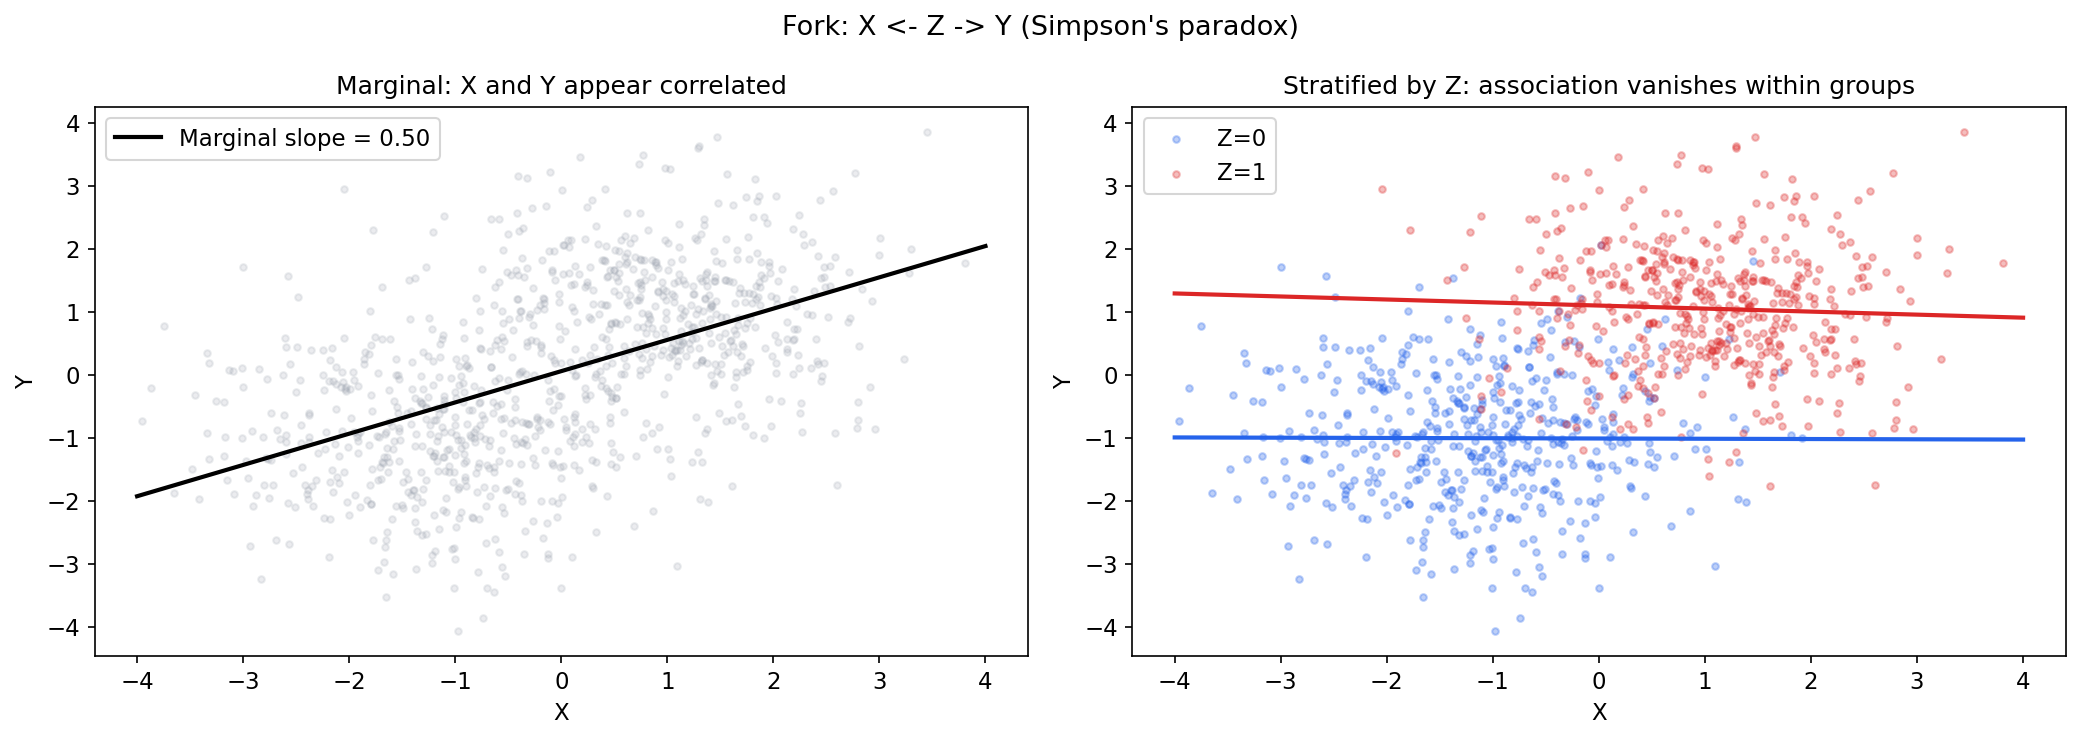

Marginal correlation: 0.508
Conditional on Z=0:  -0.004
Conditional on Z=1:  -0.047


In [2]:
def simulate_fork(n: int = 1000, seed: int = SEED) -> dict:
    """X <- Z -> Y. Binary Z, continuous X and Y."""
    rng = np.random.default_rng(seed)
    z = rng.binomial(1, 0.5, size=n)
    x = rng.normal(2 * z - 1, 1)
    y = rng.normal(2 * z - 1, 1)  # same shift, independent noise
    return {"X": x, "Y": y, "Z": z}

fork = simulate_fork()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: marginal (confounded)
ax = axes[0]
ax.scatter(fork["X"], fork["Y"], alpha=0.2, s=10, color=C_PRIOR)
coeffs = np.polyfit(fork["X"], fork["Y"], 1)
x_line = np.linspace(-4, 4, 50)
ax.plot(x_line, np.polyval(coeffs, x_line), color="black", linewidth=2,
        label=f"Marginal slope = {coeffs[0]:.2f}")
ax.set_title("Marginal: X and Y appear correlated")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.legend()

# Right: stratified (deconfounded)
ax = axes[1]
for z_val, color, label in [(0, C_POSTERIOR, "Z=0"), (1, C_LIKELIHOOD, "Z=1")]:
    mask = fork["Z"] == z_val
    ax.scatter(fork["X"][mask], fork["Y"][mask], alpha=0.3, s=10, color=color, label=label)
    c = np.polyfit(fork["X"][mask], fork["Y"][mask], 1)
    ax.plot(x_line, np.polyval(c, x_line), color=color, linewidth=2)
ax.set_title("Stratified by Z: association vanishes within groups")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.legend()

plt.suptitle("Fork: X <- Z -> Y (Simpson's paradox)", fontsize=13)
plt.tight_layout()
plt.show()

r_marginal = np.corrcoef(fork["X"], fork["Y"])[0, 1]
r_z0 = np.corrcoef(fork["X"][fork["Z"]==0], fork["Y"][fork["Z"]==0])[0, 1]
r_z1 = np.corrcoef(fork["X"][fork["Z"]==1], fork["Y"][fork["Z"]==1])[0, 1]
print(f"Marginal correlation: {r_marginal:.3f}")
print(f"Conditional on Z=0:  {r_z0:.3f}")
print(f"Conditional on Z=1:  {r_z1:.3f}")

## 2. Standardization and Prior Specification

Standardize all variables: subtract mean, divide by SD. Then:
- Intercept prior: $\alpha \sim N(0, 0.2)$ (near zero on standardized scale)
- Slope prior: $\beta \sim N(0, 0.5)$ (effects > 1 SD implausible)
- Residual: $\sigma \sim \text{Exp}(1)$

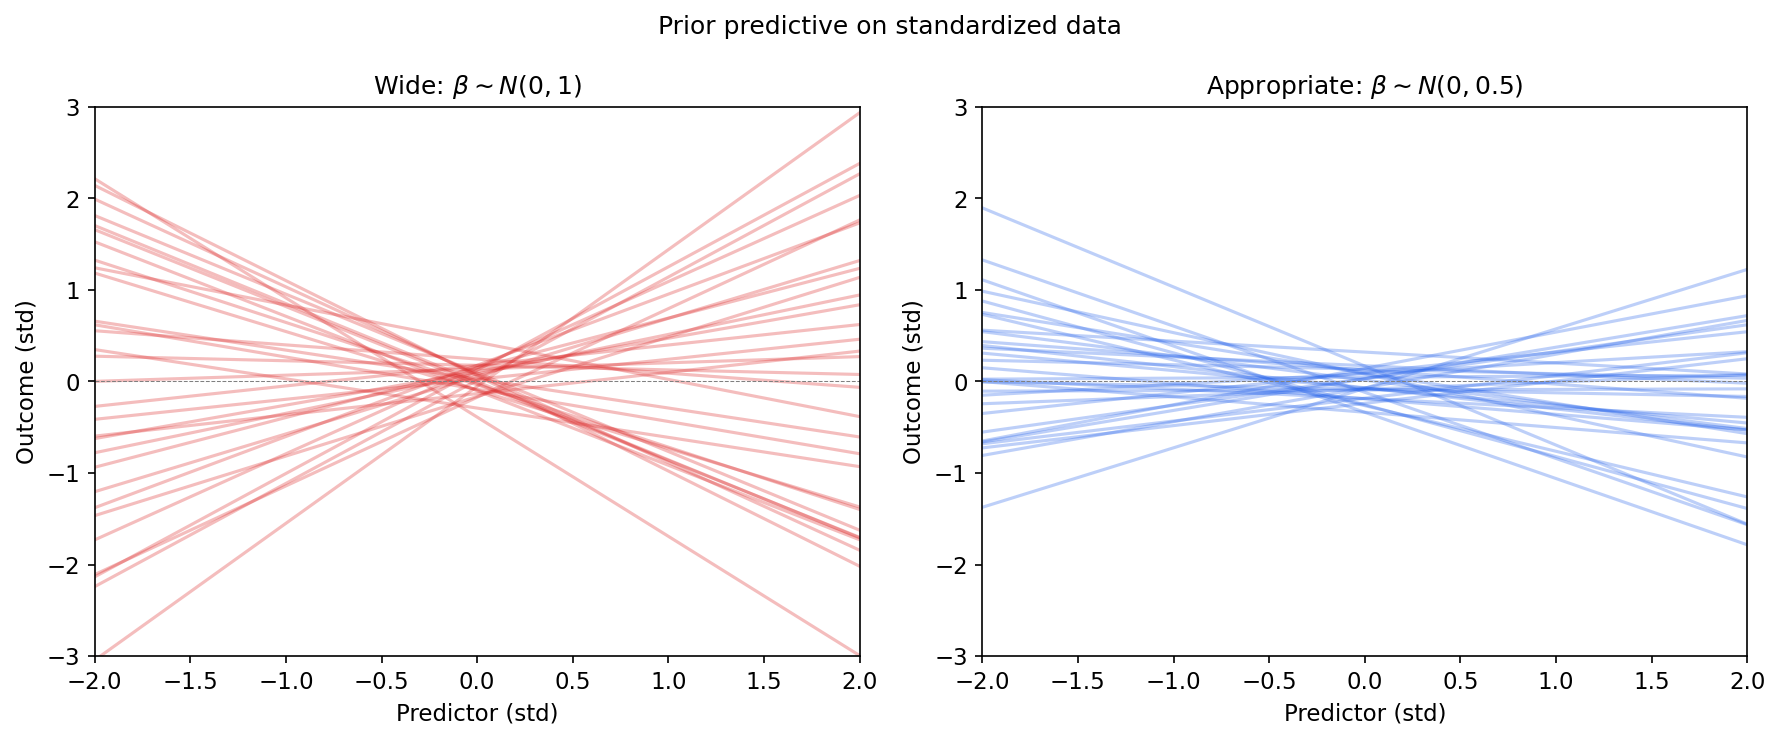

In [3]:
# Prior predictive: wide vs appropriate priors on standardized data
rng_pp = np.random.default_rng(SEED)
n_lines = 30
x_range = np.array([-2, 2])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sd, color, title in [
    (axes[0], 1.0, C_LIKELIHOOD, r"Wide: $\beta \sim N(0, 1)$"),
    (axes[1], 0.5, C_POSTERIOR, r"Appropriate: $\beta \sim N(0, 0.5)$"),
]:
    for _ in range(n_lines):
        a = rng_pp.normal(0, 0.2)
        b = rng_pp.normal(0, sd)
        ax.plot(x_range, a + b * x_range, alpha=0.3, color=color)
    ax.set_xlim(-2, 2); ax.set_ylim(-3, 3)
    ax.set_xlabel("Predictor (std)"); ax.set_ylabel("Outcome (std)")
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.suptitle("Prior predictive on standardized data", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Multiple Regression: Adjusting for the Fork

The marriage-divorce example. $A$ (age at marriage) is a fork: $M \leftarrow A \rightarrow D$.

**Without A:** marriage rate appears to predict divorce (confounded).

**With A:** marriage rate effect shrinks toward zero; age at marriage is the real driver.

$$D_i \sim \text{Normal}(\alpha + \beta_M M_i + \beta_A A_i, \sigma)$$

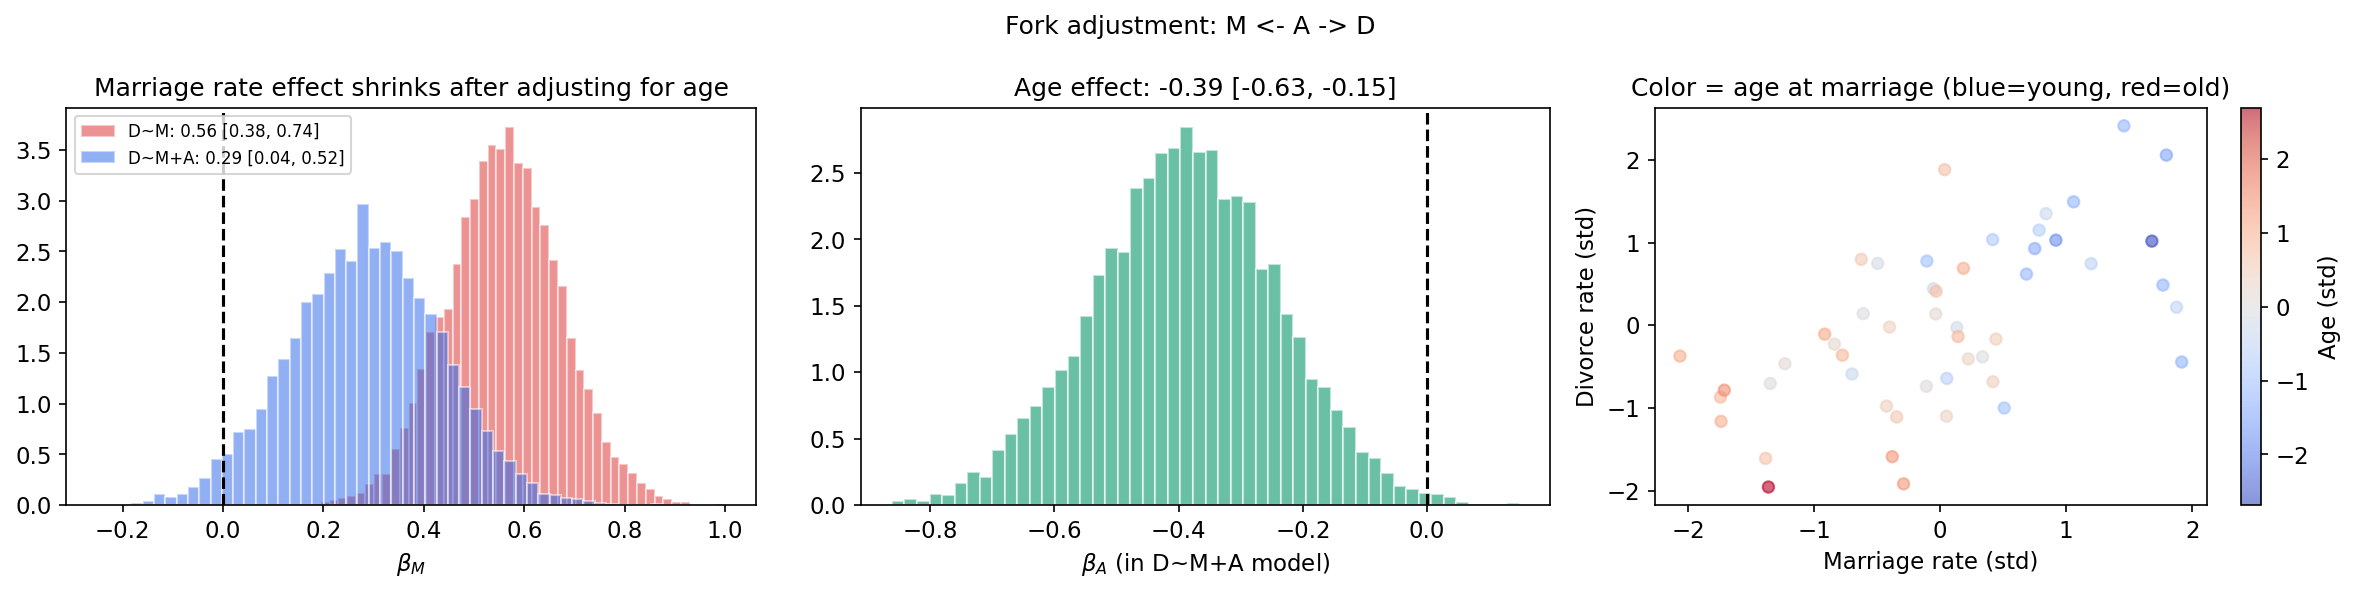

beta_M without A: 0.560 (confounded — appears to predict divorce)
beta_M with A:    0.285 (deconfounded — effect vanishes)
beta_A:           -0.389 (the real driver)


In [4]:
# Simulate marriage-divorce-age data
rng_md = np.random.default_rng(SEED)
n_states = 50

# A causes both M and D (fork)
a_raw = rng_md.normal(28, 2, size=n_states)  # median age at marriage
m_raw = 25 - 0.8 * a_raw + rng_md.normal(0, 1.5, size=n_states)  # marriage rate
d_raw = 15 - 0.5 * a_raw + 0.05 * m_raw + rng_md.normal(0, 1, size=n_states)  # divorce rate

# Standardize
a_std = standardize(a_raw)
m_std = standardize(m_raw)
d_std = standardize(d_raw)

# Model 1: D ~ M only (confounded)
fit_m_only = quap_linear(d_std, m_std[:, None])
beta_m_only = fit_m_only["samples"][:, 1]

# Model 2: D ~ M + A (adjusted for fork)
fit_ma = quap_linear(d_std, np.column_stack([m_std, a_std]))
beta_m_adj = fit_ma["samples"][:, 1]
beta_a_adj = fit_ma["samples"][:, 2]

# Model 3: D ~ A only (total effect of A)
fit_a_only = quap_linear(d_std, a_std[:, None])
beta_a_total = fit_a_only["samples"][:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# beta_M before and after adjustment
ci_m1 = np.percentile(beta_m_only, [5.5, 94.5])
ci_m2 = np.percentile(beta_m_adj, [5.5, 94.5])
axes[0].hist(beta_m_only, bins=50, density=True, alpha=0.5, color=C_LIKELIHOOD,
             edgecolor="white", label=f"D~M: {beta_m_only.mean():.2f} [{ci_m1[0]:.2f}, {ci_m1[1]:.2f}]")
axes[0].hist(beta_m_adj, bins=50, density=True, alpha=0.5, color=C_POSTERIOR,
             edgecolor="white", label=f"D~M+A: {beta_m_adj.mean():.2f} [{ci_m2[0]:.2f}, {ci_m2[1]:.2f}]")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Marriage rate effect shrinks after adjusting for age")
axes[0].set_xlabel(r"$\beta_M$"); axes[0].legend(fontsize=8)

# beta_A
ci_a = np.percentile(beta_a_adj, [5.5, 94.5])
axes[1].hist(beta_a_adj, bins=50, density=True, alpha=0.6, color=C_DATA, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title(f"Age effect: {beta_a_adj.mean():.2f} [{ci_a[0]:.2f}, {ci_a[1]:.2f}]")
axes[1].set_xlabel(r"$\beta_A$ (in D~M+A model)")

# Scatter: data with confound
axes[2].scatter(m_std, d_std, c=a_std, cmap="coolwarm", alpha=0.6, s=30)
axes[2].set_xlabel("Marriage rate (std)"); axes[2].set_ylabel("Divorce rate (std)")
axes[2].set_title("Color = age at marriage (blue=young, red=old)")
cb = plt.colorbar(axes[2].collections[0], ax=axes[2])
cb.set_label("Age (std)")

plt.suptitle("Fork adjustment: M <- A -> D", fontsize=12)
plt.tight_layout()
plt.show()

print(f"beta_M without A: {beta_m_only.mean():.3f} (confounded — appears to predict divorce)")
print(f"beta_M with A:    {beta_m_adj.mean():.3f} (deconfounded — effect vanishes)")
print(f"beta_A:           {beta_a_adj.mean():.3f} (the real driver)")

## 4. The Pipe: $X \rightarrow Z \rightarrow Y$

$Z$ is a mediator on the causal path from $X$ to $Y$. Conditioning on $Z$ blocks the indirect causal effect.

For the **total** effect of $A$ on $D$: do NOT include $M$ (it is a pipe).

For the **direct** effect of $A$ on $D$: include $M$ (blocks the indirect path $A \rightarrow M \rightarrow D$).

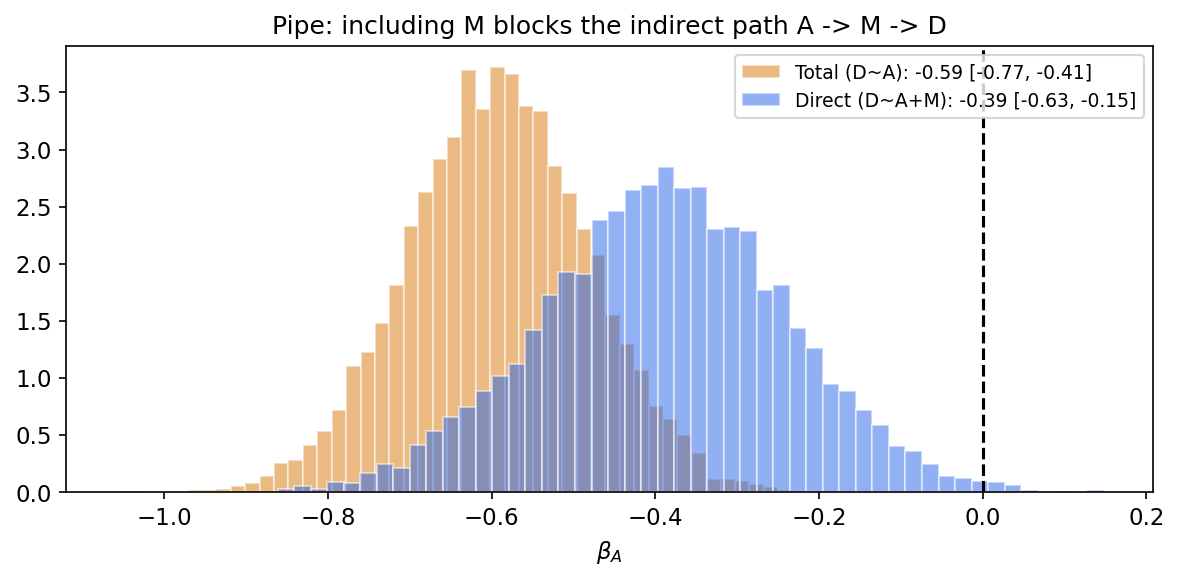

Total effect of A (includes A->M->D):  -0.592
Direct effect of A (blocks A->M->D):   -0.389
Indirect (through M):                  -0.203


In [5]:
# Demonstrate pipe blocking
# Total effect of A on D (no M)
ci_at = np.percentile(beta_a_total, [5.5, 94.5])

# Direct effect of A on D (with M — blocks pipe)
ci_ad = np.percentile(beta_a_adj, [5.5, 94.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(beta_a_total, bins=50, density=True, alpha=0.5, color=C_ACCENT, edgecolor="white",
        label=f"Total (D~A): {beta_a_total.mean():.2f} [{ci_at[0]:.2f}, {ci_at[1]:.2f}]")
ax.hist(beta_a_adj, bins=50, density=True, alpha=0.5, color=C_POSTERIOR, edgecolor="white",
        label=f"Direct (D~A+M): {beta_a_adj.mean():.2f} [{ci_ad[0]:.2f}, {ci_ad[1]:.2f}]")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel(r"$\beta_A$")
ax.set_title("Pipe: including M blocks the indirect path A -> M -> D")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total effect of A (includes A->M->D):  {beta_a_total.mean():.3f}")
print(f"Direct effect of A (blocks A->M->D):   {beta_a_adj.mean():.3f}")
print(f"Indirect (through M):                  {beta_a_total.mean() - beta_a_adj.mean():.3f}")

## 5. Simulating Interventions: do(M)

A causal effect is a manipulation: delete arrows into $M$, set $M$ to a value, simulate $D$.

In additive linear models, the intervention contrast equals $\beta_M \cdot \Delta M$. We simulate to build the habit for nonlinear models.

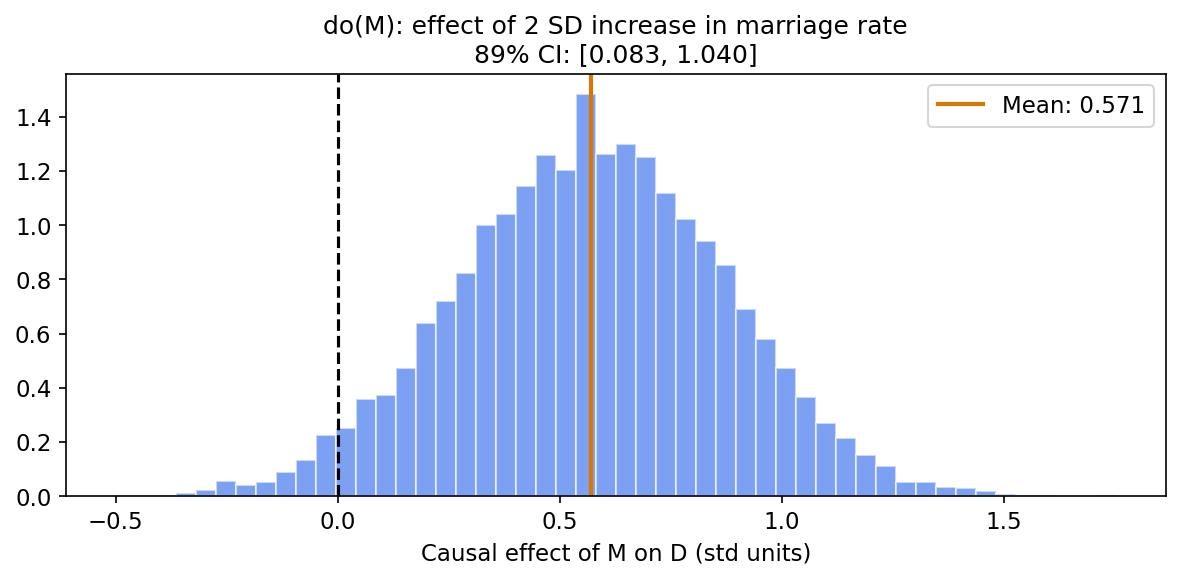

In additive model: effect = beta_M * (m_high - m_low) = 0.285 * 2.0 = 0.571
Simulation confirms: 0.571
For nonlinear models, only the simulation approach gives the correct causal effect.


In [6]:
# Simulate do(M): set M to low vs high, predict D
samp_ma = fit_ma["samples"]  # [alpha, beta_M, beta_A, sigma]

m_low, m_high = -1.0, 1.0  # 1 SD below and above mean
rng_do = np.random.default_rng(SEED)

# For each posterior sample, simulate intervention
n_sim = 500
effects = np.zeros(N_SAMPLES)
for i in range(N_SAMPLES):
    alpha_i = samp_ma[i, 0]
    bm_i = samp_ma[i, 1]
    ba_i = samp_ma[i, 2]

    # Sample A from data distribution
    a_sim = rng_do.choice(a_std, size=n_sim, replace=True)

    d_low = alpha_i + bm_i * m_low + ba_i * a_sim
    d_high = alpha_i + bm_i * m_high + ba_i * a_sim
    effects[i] = np.mean(d_high - d_low)

ci_eff = np.percentile(effects, [5.5, 94.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(effects, bins=50, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
ax.axvline(0, color="black", linestyle="--")
ax.axvline(effects.mean(), color=C_ACCENT, linewidth=2, label=f"Mean: {effects.mean():.3f}")
ax.set_xlabel("Causal effect of M on D (std units)")
ax.set_title(f"do(M): effect of 2 SD increase in marriage rate\n89% CI: [{ci_eff[0]:.3f}, {ci_eff[1]:.3f}]")
ax.legend()
plt.tight_layout()
plt.show()

print(f"In additive model: effect = beta_M * (m_high - m_low) = {samp_ma[:, 1].mean():.3f} * {m_high - m_low:.1f} = {samp_ma[:, 1].mean() * (m_high - m_low):.3f}")
print(f"Simulation confirms: {effects.mean():.3f}")
print("For nonlinear models, only the simulation approach gives the correct causal effect.")

---

# Part 2: Applied Exercises with Slovenian Data

## The four elemental confounds applied to real datasets.

In [7]:
# Load datasets
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")
crime = pd.read_csv(DATA_DIR / "sr2026_crime.csv")

YEAR_MIN = 2022

## Exercise 1: Fork — Salary Confounds the Permits-Price Association

**DAG:** $\text{Permits} \leftarrow \text{Salary} \rightarrow \text{Price}$

Municipalities with higher salaries have both more building permits and higher property prices. The permits-price correlation is confounded by salary.

**Estimand:** Does permit activity ($M$) directly cause higher prices ($D$), or is salary ($A$) the common cause?

From `DATA_CATALOG.md`: "avg_gross_salary -> permits_per_1000 -> median_price_m2" and "avg_gross_salary as fork confounding permits-price relationship."

Municipalities (2024): 182


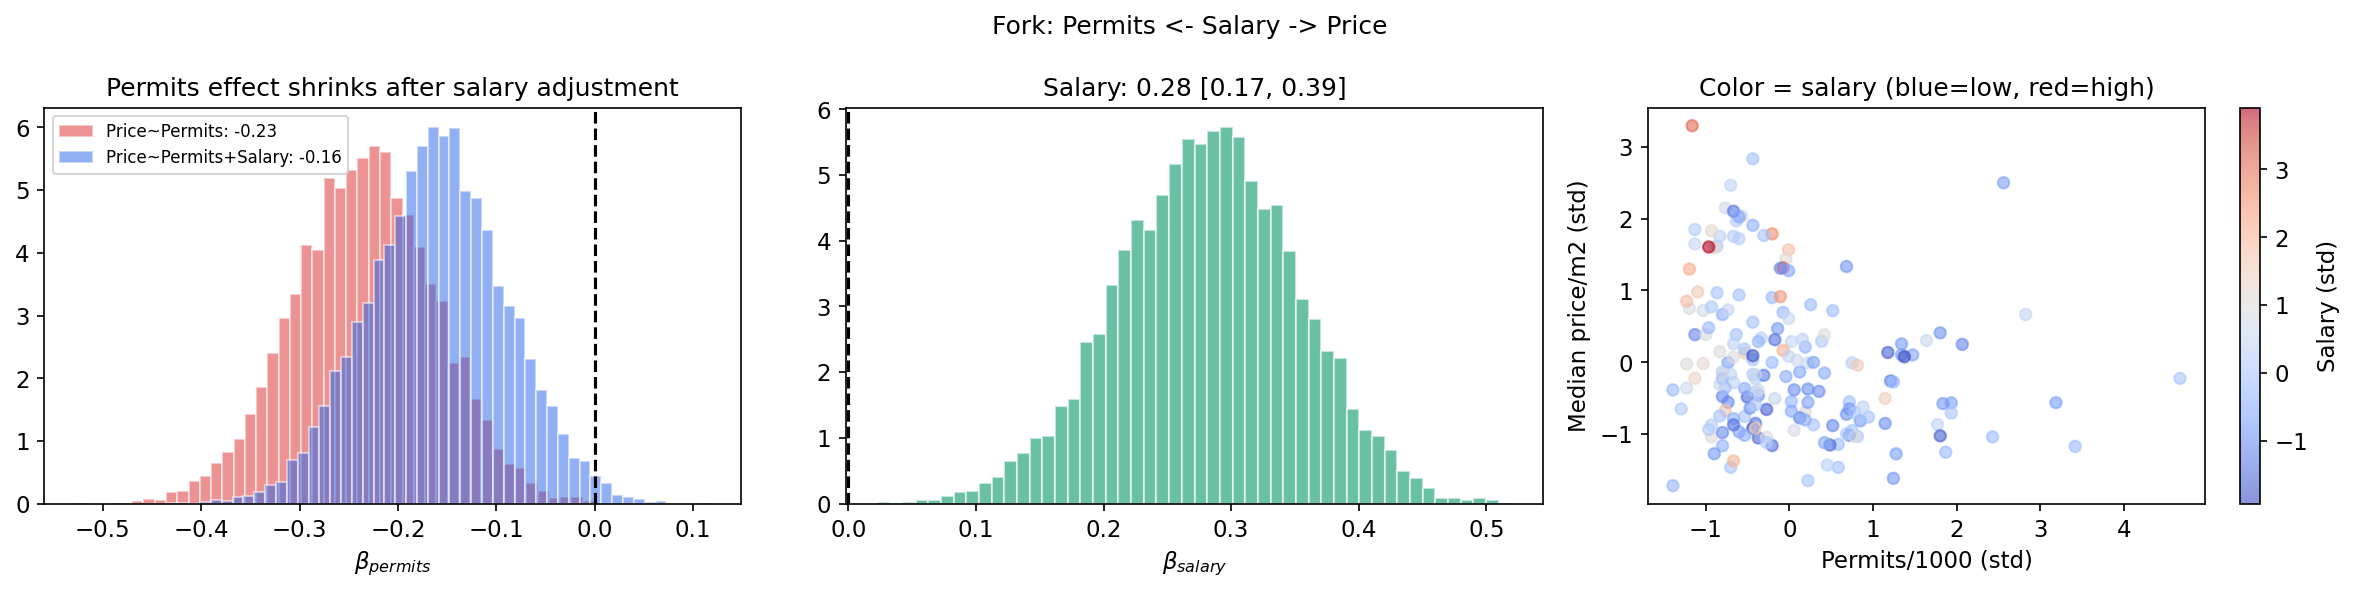

beta_permits without salary: -0.233 (confounded)
beta_permits with salary:    -0.159 (deconfounded)
Salary is the common cause. Permits alone do not drive prices.


In [8]:
# Municipality panel: salary, permits, price
latest_year = mun["year"].max()
mun_clean = mun[
    (mun["year"] == latest_year)
    & mun["avg_gross_salary"].notna()
    & mun["permits_per_1000"].notna()
    & mun["median_price_m2"].notna()
].copy()

# Standardize
mun_clean["sal_s"] = standardize(mun_clean["avg_gross_salary"].values)
mun_clean["per_s"] = standardize(mun_clean["permits_per_1000"].values)
mun_clean["pri_s"] = standardize(mun_clean["median_price_m2"].values)

print(f"Municipalities ({latest_year}): {len(mun_clean)}")

# Model 1: Price ~ Permits (confounded)
fit_p_only = quap_linear(mun_clean["pri_s"].values, mun_clean["per_s"].values[:, None])
beta_p_only = fit_p_only["samples"][:, 1]

# Model 2: Price ~ Permits + Salary (adjusted)
X_ps = np.column_stack([mun_clean["per_s"].values, mun_clean["sal_s"].values])
fit_ps = quap_linear(mun_clean["pri_s"].values, X_ps)
beta_p_adj = fit_ps["samples"][:, 1]
beta_sal = fit_ps["samples"][:, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# beta_permits before/after
ci1 = np.percentile(beta_p_only, [5.5, 94.5])
ci2 = np.percentile(beta_p_adj, [5.5, 94.5])
axes[0].hist(beta_p_only, bins=50, density=True, alpha=0.5, color=C_LIKELIHOOD, edgecolor="white",
             label=f"Price~Permits: {beta_p_only.mean():.2f}")
axes[0].hist(beta_p_adj, bins=50, density=True, alpha=0.5, color=C_POSTERIOR, edgecolor="white",
             label=f"Price~Permits+Salary: {beta_p_adj.mean():.2f}")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Permits effect shrinks after salary adjustment")
axes[0].set_xlabel(r"$\beta_{permits}$"); axes[0].legend(fontsize=8)

# beta_salary
ci_s = np.percentile(beta_sal, [5.5, 94.5])
axes[1].hist(beta_sal, bins=50, density=True, alpha=0.6, color=C_DATA, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title(f"Salary: {beta_sal.mean():.2f} [{ci_s[0]:.2f}, {ci_s[1]:.2f}]")
axes[1].set_xlabel(r"$\beta_{salary}$")

# Scatter colored by salary
axes[2].scatter(mun_clean["per_s"], mun_clean["pri_s"],
                c=mun_clean["sal_s"], cmap="coolwarm", alpha=0.6, s=30)
axes[2].set_xlabel("Permits/1000 (std)"); axes[2].set_ylabel("Median price/m2 (std)")
axes[2].set_title("Color = salary (blue=low, red=high)")
plt.colorbar(axes[2].collections[0], ax=axes[2]).set_label("Salary (std)")

plt.suptitle("Fork: Permits <- Salary -> Price", fontsize=12)
plt.tight_layout()
plt.show()

print(f"beta_permits without salary: {beta_p_only.mean():.3f} (confounded)")
print(f"beta_permits with salary:    {beta_p_adj.mean():.3f} (deconfounded)")
print(f"Salary is the common cause. Permits alone do not drive prices.")

## Exercise 2: Pipe — Year Built Mediates Municipality → Price

**DAG:** $\text{Municipality} \rightarrow \text{YearBuilt} \rightarrow \text{Price}$, $\text{Municipality} \rightarrow \text{Price}$

Desirable municipalities attract newer construction, and newer properties cost more. Year built is a **pipe** (mediator).

**For total effect of municipality:** do NOT control for year_built.

**For direct effect:** control for year_built (isolates location premium from building quality).

Ljubljana: 3,435 apartments
Maribor:   1,788 apartments
Mean year built — LJ: 1976, MB: 1968


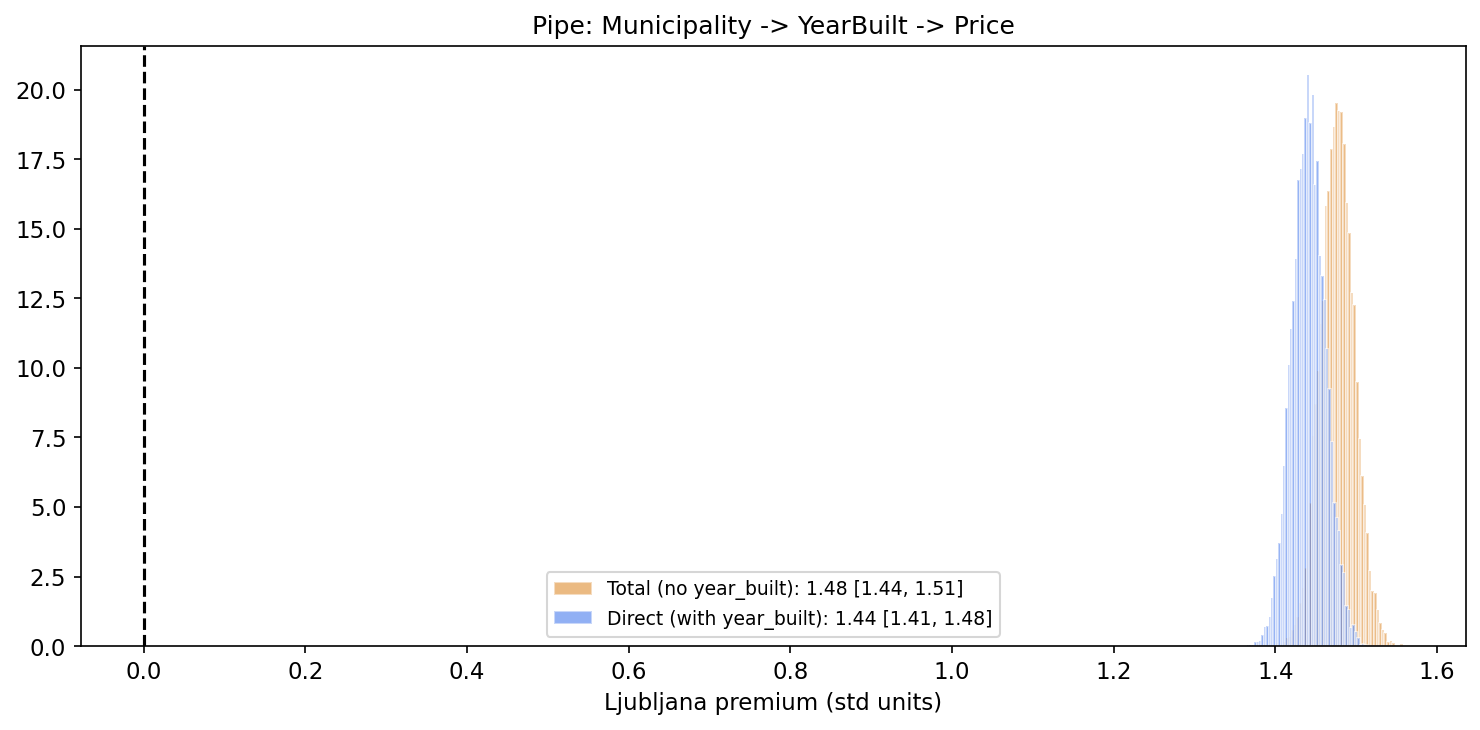

Total Ljubljana premium:  1.477 SD
Direct (same year built): 1.442 SD
Indirect (through newer buildings): 0.036 SD

2% of the premium is mediated through building age.


In [9]:
# Ljubljana vs Maribor apartments, 2022+
lj_mb = re[
    (re["year"] >= YEAR_MIN)
    & (re["property_type"] == "apartment")
    & (re["municipality"].isin(["LJUBLJANA", "MARIBOR"]))
    & re["price_per_m2"].notna()
    & re["year_built"].notna()
    & (re["year_built"] > 1900) & (re["year_built"] <= 2025)
].copy()

lj_mb["is_lj"] = (lj_mb["municipality"] == "LJUBLJANA").astype(int)
lj_mb["price_s"] = standardize(lj_mb["price_per_m2"].values)
lj_mb["yb_s"] = standardize(lj_mb["year_built"].values)

print(f"Ljubljana: {(lj_mb['is_lj']==1).sum():,} apartments")
print(f"Maribor:   {(lj_mb['is_lj']==0).sum():,} apartments")
print(f"Mean year built — LJ: {lj_mb.loc[lj_mb['is_lj']==1, 'year_built'].mean():.0f}, "
      f"MB: {lj_mb.loc[lj_mb['is_lj']==0, 'year_built'].mean():.0f}")

# Total effect: Price ~ Municipality
fit_total_mun = quap_linear(lj_mb["price_s"].values, lj_mb["is_lj"].values[:, None],
                             prior_sd_beta=1.0, prior_sd_alpha=0.5)
beta_mun_total = fit_total_mun["samples"][:, 1]

# Direct effect: Price ~ Municipality + YearBuilt (blocks pipe)
X_my = np.column_stack([lj_mb["is_lj"].values, lj_mb["yb_s"].values])
fit_direct_mun = quap_linear(lj_mb["price_s"].values, X_my,
                              prior_sd_beta=1.0, prior_sd_alpha=0.5)
beta_mun_direct = fit_direct_mun["samples"][:, 1]
beta_yb = fit_direct_mun["samples"][:, 2]

fig, ax = plt.subplots(figsize=(10, 5))
ci_t = np.percentile(beta_mun_total, [5.5, 94.5])
ci_d = np.percentile(beta_mun_direct, [5.5, 94.5])

ax.hist(beta_mun_total, bins=50, density=True, alpha=0.5, color=C_ACCENT, edgecolor="white",
        label=f"Total (no year_built): {beta_mun_total.mean():.2f} [{ci_t[0]:.2f}, {ci_t[1]:.2f}]")
ax.hist(beta_mun_direct, bins=50, density=True, alpha=0.5, color=C_POSTERIOR, edgecolor="white",
        label=f"Direct (with year_built): {beta_mun_direct.mean():.2f} [{ci_d[0]:.2f}, {ci_d[1]:.2f}]")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Ljubljana premium (std units)")
ax.set_title("Pipe: Municipality -> YearBuilt -> Price")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

indirect = beta_mun_total.mean() - beta_mun_direct.mean()
print(f"Total Ljubljana premium:  {beta_mun_total.mean():.3f} SD")
print(f"Direct (same year built): {beta_mun_direct.mean():.3f} SD")
print(f"Indirect (through newer buildings): {indirect:.3f} SD")
print(f"\n{abs(indirect)/abs(beta_mun_total.mean())*100:.0f}% of the premium is mediated through building age.")

## Exercise 3: Forensic Audio — Device as Fork Confound

**DAG:** $\text{ENF\_SNR} \leftarrow \text{Device} \rightarrow \text{Bandwidth}$

Device quality causes both higher ENF SNR and higher bandwidth. The ENF-bandwidth correlation is confounded.

**Without device adjustment:** bandwidth appears to predict ENF SNR.

**With device adjustment:** the association weakens or vanishes.

Recordings with top 4 devices: 168


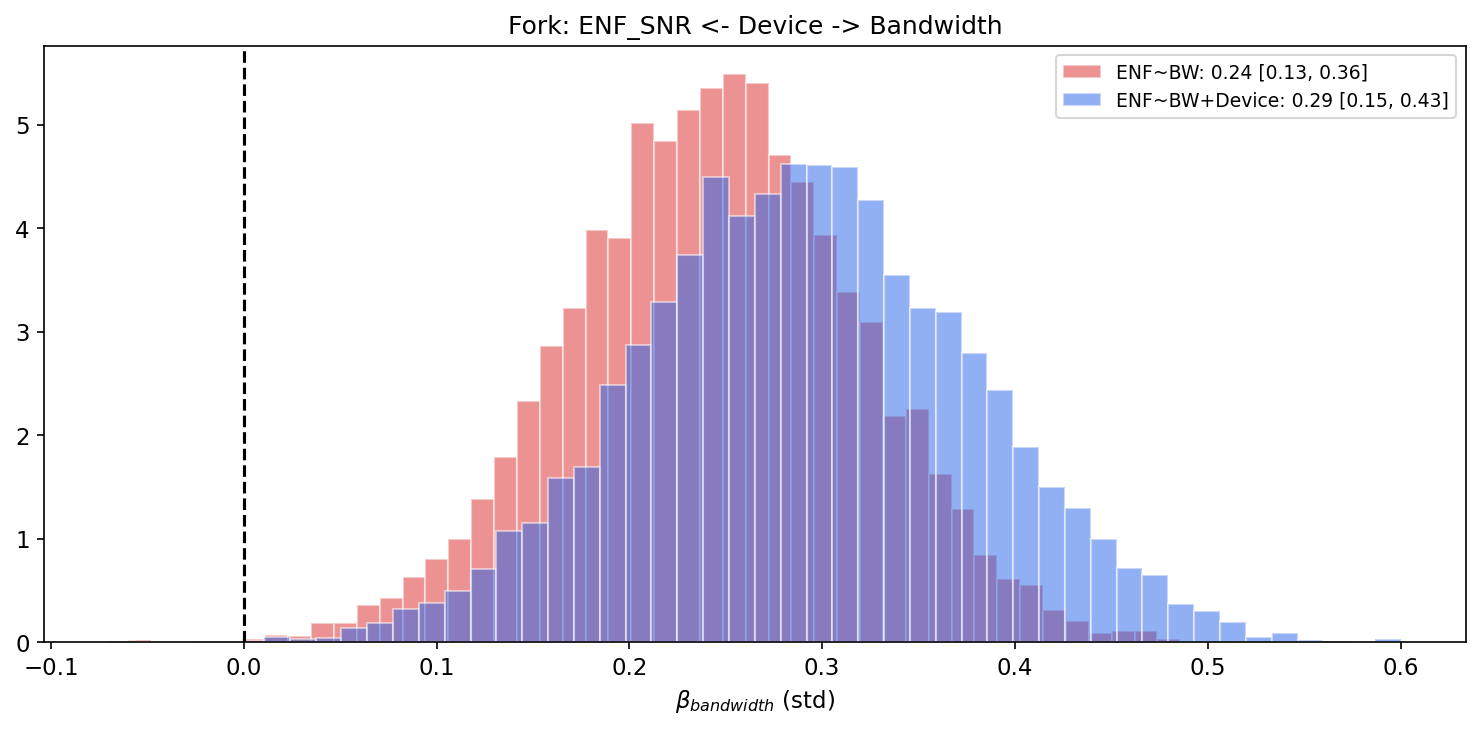

beta_bandwidth without device: 0.245 (confounded)
beta_bandwidth with device:    0.291 (deconfounded)
Device quality is the common cause. Bandwidth alone does not predict ENF quality.
Failing to adjust would bias forensic detection system calibration.


In [10]:
# Forensic: ENF_SNR ~ bandwidth, with and without device adjustment
for_clean = forensic[
    forensic["enf_snr_50hz"].notna()
    & forensic["bandwidth_hz"].notna()
    & forensic["device"].notna()
].copy()

# Create device dummies (index coding via one-hot for multiple devices)
top_devs = for_clean["device"].value_counts().head(4).index.tolist()
for_dev = for_clean[for_clean["device"].isin(top_devs)].copy()
for_dev["enf_s"] = standardize(for_dev["enf_snr_50hz"].values)
for_dev["bw_s"] = standardize(for_dev["bandwidth_hz"].values)

# Create device indicator columns (excluding first as reference for regression)
dev_dummies = pd.get_dummies(for_dev["device"], drop_first=True, dtype=float)
dev_cols = dev_dummies.values

print(f"Recordings with top 4 devices: {len(for_dev)}")

# Model 1: ENF ~ bandwidth (confounded)
fit_bw = quap_linear(for_dev["enf_s"].values, for_dev["bw_s"].values[:, None])
beta_bw_only = fit_bw["samples"][:, 1]

# Model 2: ENF ~ bandwidth + device indicators (adjusted)
X_bd = np.column_stack([for_dev["bw_s"].values, dev_cols])
fit_bd = quap_linear(for_dev["enf_s"].values, X_bd)
beta_bw_adj = fit_bd["samples"][:, 1]

fig, ax = plt.subplots(figsize=(10, 5))
ci1 = np.percentile(beta_bw_only, [5.5, 94.5])
ci2 = np.percentile(beta_bw_adj, [5.5, 94.5])

ax.hist(beta_bw_only, bins=50, density=True, alpha=0.5, color=C_LIKELIHOOD, edgecolor="white",
        label=f"ENF~BW: {beta_bw_only.mean():.2f} [{ci1[0]:.2f}, {ci1[1]:.2f}]")
ax.hist(beta_bw_adj, bins=50, density=True, alpha=0.5, color=C_POSTERIOR, edgecolor="white",
        label=f"ENF~BW+Device: {beta_bw_adj.mean():.2f} [{ci2[0]:.2f}, {ci2[1]:.2f}]")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel(r"$\beta_{bandwidth}$ (std)")
ax.set_title("Fork: ENF_SNR <- Device -> Bandwidth")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"beta_bandwidth without device: {beta_bw_only.mean():.3f} (confounded)")
print(f"beta_bandwidth with device:    {beta_bw_adj.mean():.3f} (deconfounded)")
print("Device quality is the common cause. Bandwidth alone does not predict ENF quality.")
print("Failing to adjust would bias forensic detection system calibration.")

## Exercise 4: Simulating do(Salary) — Causal Effect on Municipality Prices

**Intervention:** If we could increase average salary by 1 SD in a municipality, how much would median price change?

Uses the adjusted model from Exercise 1. Simulates the intervention by sampling from the posterior and setting salary to different values.

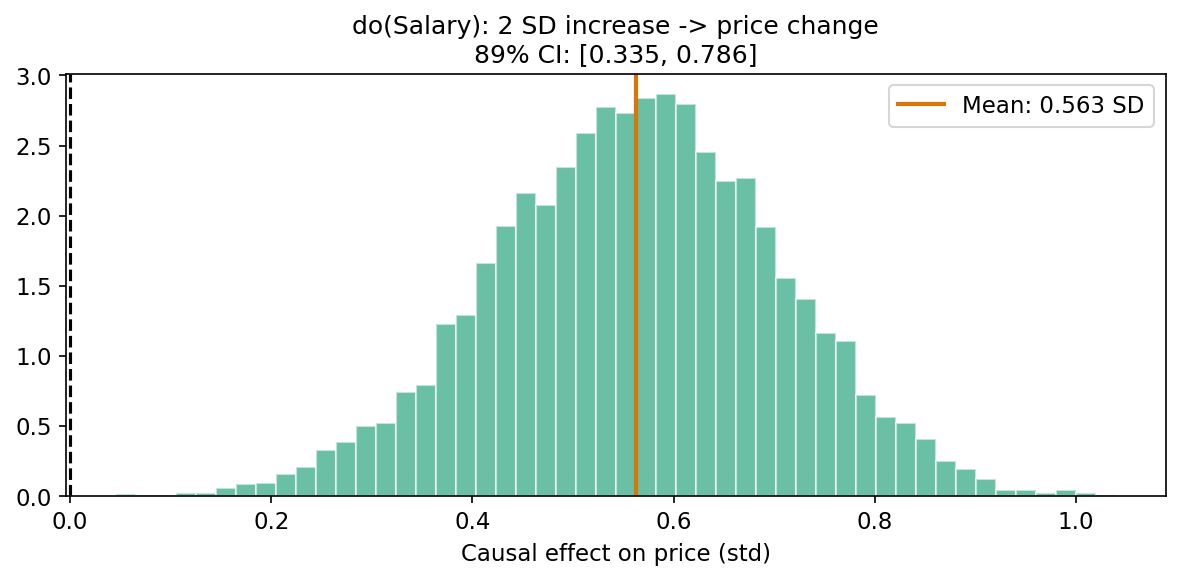

In EUR: 1 SD salary increase (196 EUR/month)
  -> 410 EUR/m2 price increase [244, 573]


In [11]:
# Simulate do(Salary)
samp_ps = fit_ps["samples"]  # [alpha, beta_permits, beta_salary, sigma]
per_s = mun_clean["per_s"].values

sal_low, sal_high = -1.0, 1.0  # 1 SD below and above mean
rng_do2 = np.random.default_rng(SEED)

effects_sal = np.zeros(N_SAMPLES)
for i in range(N_SAMPLES):
    a_i = samp_ps[i, 0]
    bp_i = samp_ps[i, 1]
    bs_i = samp_ps[i, 2]

    # Sample permits from data
    p_sim = rng_do2.choice(per_s, size=200, replace=True)

    d_low = a_i + bp_i * p_sim + bs_i * sal_low
    d_high = a_i + bp_i * p_sim + bs_i * sal_high
    effects_sal[i] = np.mean(d_high - d_low)

ci_sal = np.percentile(effects_sal, [5.5, 94.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(effects_sal, bins=50, density=True, alpha=0.6, color=C_DATA, edgecolor="white")
ax.axvline(0, color="black", linestyle="--")
ax.axvline(effects_sal.mean(), color=C_ACCENT, linewidth=2,
           label=f"Mean: {effects_sal.mean():.3f} SD")
ax.set_xlabel("Causal effect on price (std)")
ax.set_title(f"do(Salary): 2 SD increase -> price change\n89% CI: [{ci_sal[0]:.3f}, {ci_sal[1]:.3f}]")
ax.legend()
plt.tight_layout()
plt.show()

# Convert back to EUR scale
price_sd = mun_clean["median_price_m2"].std()
sal_sd = mun_clean["avg_gross_salary"].std()
print(f"In EUR: 1 SD salary increase ({sal_sd:.0f} EUR/month)")
print(f"  -> {effects_sal.mean() * price_sd:.0f} EUR/m2 price increase [{ci_sal[0]*price_sd:.0f}, {ci_sal[1]*price_sd:.0f}]")

---

# Key Takeaways

1. **Forks create spurious associations.** Building permits and prices are correlated because salary drives both. Bandwidth and ENF SNR are correlated because device quality drives both. Stratifying by the common cause removes the spurious correlation.

2. **Pipes carry causal information.** Year built mediates the Ljubljana-Maribor price gap. Controlling for year built gives the direct location premium but loses the indirect effect through newer construction. The estimand determines whether to control.

3. **Standardize for priors.** $\beta \sim N(0, 0.5)$ on standardized data means "effects > 1 SD are unlikely." This works across domains: real estate, forensics, macro.

4. **Simulate interventions.** do(Salary) gives the causal effect of salary on price, properly adjusted for the permit confound. In additive models this equals the coefficient times the contrast. For nonlinear models, only simulation works.

5. **The coefficient is not always the causal effect.** In these linear models it happens to be. Build the simulation habit now for when you move to logistic, Poisson, and hierarchical models.

6. **Forensic calibration needs confound adjustment.** Without device correction, bandwidth appears to predict ENF quality. This would bias the detection system. The fork DAG tells you to adjust for device before interpreting bandwidth effects.

**Next:** [[Lecture A07]] covers colliders and descendants, the dangerous confounds where conditioning *creates* spurious associations.